In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import copy
import os

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()  #调用父类 nn.Module 的初始化函数
        self.fc = nn.Linear(28 * 28, 10)#数学原理：执行 y = xA^T + b

    def forward(self, x):#forward前向传播
        x = x.view(x.size(0), -1)  #把四维张量化为二维张量
        return self.fc(x)

#下载dataset数据库
transform = transforms.ToTensor()
dataset = datasets.MNIST(
    root=os.path.expanduser('~/data'),
    train=True,  #True 表示加载训练集图片（给模型学习用）；如果设为 False，则加载 测试集图片（给模型考试用）
    download=True,  #如果指定的 root 路径里没有数据，程序会自动从互联网下载。如果已经下载过了，它会直接读取
    transform=transform #把每张图都变成张量
)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import copy
import os

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()  #调用父类 nn.Module 的初始化函数
        self.fc = nn.Linear(28 * 28, 10)#数学原理：执行 y = xA^T + b

    def forward(self, x):#forward前向传播
        x = x.view(x.size(0), -1)  #把四维张量化为二维张量
        return self.fc(x)

#下载dataset数据库
transform = transforms.ToTensor()
dataset = datasets.MNIST(
    root=os.path.expanduser('~/data'),
    train=True,  #True 表示加载训练集图片（给模型学习用）；如果设为 False，则加载 测试集图片（给模型考试用）
    download=True,  #如果指定的 root 路径里没有数据，程序会自动从互联网下载。如果已经下载过了，它会直接读取
    transform=transform #把每张图都变成张量
)

In [8]:
# 1. 准备测试集
test_dataset = datasets.MNIST("C:\\Users\\20550\\data", train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

def test(model, test_loader):
    # 1. 切换到评价模式（不更新权重，不使用 Dropout 等）
    model.eval()
    
    correct = 0
    total = 0
    
    # 2. 告诉 PyTorch：测试时不需要计算梯度（省内存，跑得快）
    with torch.no_grad():
        for data, target in test_loader:
            # 前向传播算得分 y
            output = model(data)
            
            # 找到得分最高的那个数字的索引
            # output.data 形状是 [64, 10]，1 代表在第 1 维度（10个得分）找最大
            _, predicted = torch.max(output.data, 1)
            
            # 统计总数和猜对的数量
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = 100 * correct / total
    print(f'测试集准确率: {accuracy:.2f}%')
    return accuracy

# 设定训练 5 轮
for r in range(5):
    print(f"\n--- 第 {r+1} 轮联邦学习开始 ---")
    local_weights = []
    
    # --- 阶段 A：每个客户端本地训练 ---
    for i in range(num_clients):
        # 必须 deepcopy，保证大家起点一致
        local_model = copy.deepcopy(global_model)
        
        # 本地训练，返回训练好的权重 w
        w = local_train(local_model, client_loaders[i])
        local_weights.append(w)
        print(f"客户端 {i} 训练完成")

    # --- 阶段 B：服务器聚合 ---
    global_weights = fedavg(local_weights)
    
    # --- 阶段 C：更新全局模型 ---
    global_model.load_state_dict(global_weights)

    # --- 阶段 D：【就在这里添加测试代码】 ---
    print(f"第 {r+1} 轮聚合完毕，正在测试全局模型...")
    test(global_model, test_loader)


--- 第 1 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 1 轮聚合完毕，正在测试全局模型...
测试集准确率: 90.86%

--- 第 2 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 2 轮聚合完毕，正在测试全局模型...
测试集准确率: 91.23%

--- 第 3 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 3 轮聚合完毕，正在测试全局模型...
测试集准确率: 91.61%

--- 第 4 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 4 轮聚合完毕，正在测试全局模型...
测试集准确率: 91.72%

--- 第 5 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 5 轮聚合完毕，正在测试全局模型...
测试集准确率: 91.87%


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

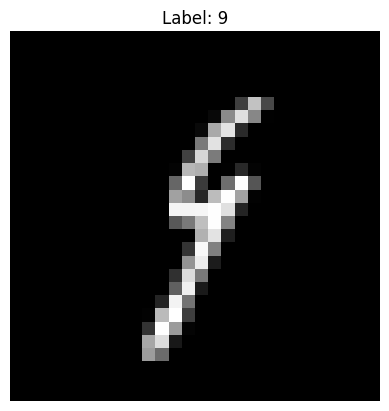

In [9]:
import matplotlib.pyplot as plt

data, target = next(iter(client_loaders[0]))

plt.imshow(data[0][0], cmap='gray')
plt.title(f"Label: {target[0].item()}")
plt.axis('off')

In [10]:
global_model.eval()#对抗样本：模型原本预测正确，你几乎不改图片模型，突然预测成另一个数字，而且很自信

data, target = next(iter(test_loader))
data = data[:1]      # 只取一张
target = target[:1]

output = global_model(data)
pred = output.argmax(dim=1)

print("真实标签:", target.item())
print("模型预测:", pred.item())

真实标签: 7
模型预测: 7


In [11]:
data.requires_grad = True
criterion = nn.CrossEntropyLoss()
output = global_model(data)
loss = criterion(output, target)
loss.backward()#计算“数据梯度”以便下面生成对抗样本(训练时算的是模型的参数梯度，和此处不同)

In [12]:
epsilon = 0.15 # 扰动强度，可调

adv_data = data + epsilon * data.grad.sign()#梯度的符号（data.grad.sign）代表了 “损失上升最快的方向”，只取方向（而非具体梯度值），能保证扰动是 “最有效” 的，且幅度可控。
adv_data = torch.clamp(adv_data, 0, 1)

In [13]:
adv_output = global_model(adv_data)
adv_pred = adv_output.argmax(dim=1)

print("对抗样本预测:", adv_pred.item())
print("置信度:", torch.softmax(adv_output, dim=1)[0][adv_pred].item())

对抗样本预测: 3
置信度: 0.7053108215332031


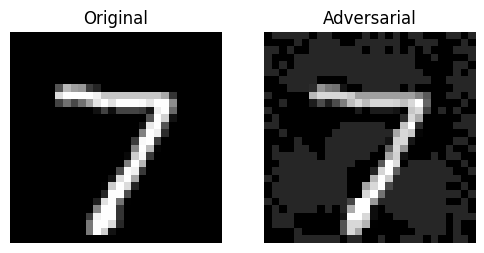

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(data[0][0].detach(), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(adv_data[0][0].detach(), cmap='gray')
plt.title("Adversarial")
plt.axis('off')

plt.show()

In [18]:
data.grad.shape


torch.Size([1, 1, 28, 28])